In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
import os

import numpy as np
from sklearn.utils.class_weight import compute_class_weight

In [2]:
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.18.0
GPU available: []


In [3]:
# DATA_DIR = "data/split"
DATA_DIR = "../data/split"

IMG_SIZE = (224, 224)
BATCH_SIZE = 64
EPOCHS = 40


In [4]:
# train_gen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=20,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     zoom_range=0.2,
#     horizontal_flip=True
# )

# val_gen = ImageDataGenerator(rescale=1./255)

train_gen = ImageDataGenerator(
    rescale=1./255,
    
    # Geometric transformations
    rotation_range=40,           # 20 -> 40 (xoay mạnh hơn)
    width_shift_range=0.2,       # 0.1 -> 0.2 (dịch ngang)
    height_shift_range=0.2,      # 0.1 -> 0.2 (dịch dọc)
    shear_range=0.2,             # (biến dạng)
    zoom_range=0.3,              # 0.2 → 0.3 (zoom)
    horizontal_flip=True,
    vertical_flip=True,          # (lật dọc)
    
    # Color/brightness augmentation
    brightness_range=[0.7, 1.3], # Thay đổi độ sáng ±30%
    fill_mode='nearest'          # Cách fill pixel khi transform
)

val_gen = ImageDataGenerator(rescale=1./255)

val_gen = ImageDataGenerator(rescale=1./255)

print(" Augmentation config:")
print("  - Rotation: ±40°")
print("  - Shift: ±20%")
print("  - Zoom: ±30%")
print("  - Brightness: ±30%")
print("  - Flips: horizontal + vertical")

 Augmentation config:
  - Rotation: ±40°
  - Shift: ±20%
  - Zoom: ±30%
  - Brightness: ±30%
  - Flips: horizontal + vertical


In [5]:
train_data = train_gen.flow_from_directory(
    os.path.join(DATA_DIR, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_data = val_gen.flow_from_directory(
    os.path.join(DATA_DIR, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)


Found 18510 images belonging to 11 classes.
Found 3968 images belonging to 11 classes.


In [8]:
# # Đếm số samples mỗi class
# class_counts = {}
# for class_name, class_idx in train_data.class_indices.items():
#     class_dir = os.path.join(DATA_DIR, "train", class_name)
#     count = len(os.listdir(class_dir))
#     class_counts[class_idx] = count

# print("Class distribution:")
# for class_name, class_idx in sorted(train_data.class_indices.items(), key=lambda x: x[1]):
#     print(f"  {class_name:25s}: {class_counts[class_idx]:5d} samples")

# # Tính class weights (cân bằng tự động)
# classes = np.array(list(class_counts.keys()))
# samples = np.array(list(class_counts.values()))

# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=classes,
#     y=np.repeat(classes, samples)  # Tạo array với số lượng tương ứng
# )

# # Convert to dict
# class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# print("\nClass weights (higher = more important):")
# for class_name, class_idx in sorted(train_data.class_indices.items(), key=lambda x: x[1]):
#     print(f"  {class_name:25s}: {class_weight_dict[class_idx]:.3f}")

# Đếm số samples mỗi class trong train set
class_counts = {}
for class_name, class_idx in train_data.class_indices.items():
    class_dir = os.path.join(DATA_DIR, "train", class_name)
    count = len([f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
    class_counts[class_idx] = count

print("\n" + "="*70)
print("CLASS DISTRIBUTION (Training Set)")
print("="*70)

total_samples = sum(class_counts.values())
for class_name, class_idx in sorted(train_data.class_indices.items(), key=lambda x: x[1]):
    count = class_counts[class_idx]
    percentage = count / total_samples * 100
    bar = "█" * int(percentage / 2)  # Visual bar
    print(f"{class_name:25s}: {count:5d} ({percentage:5.1f}%) {bar}")

# Tính class weights tự động (cân bằng)
classes = np.array(list(class_counts.keys()))
samples = np.array(list(class_counts.values()))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=np.repeat(classes, samples)
)

# Convert to dict
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print("\n" + "="*70)
print("CLASS WEIGHTS (Higher = More Important)")
print("="*70)
for class_name, class_idx in sorted(train_data.class_indices.items(), key=lambda x: x[1]):
    weight = class_weight_dict[class_idx]
    stars = "x" * int(weight * 2)  # Visual indicator
    print(f"{class_name:25s}: {weight:6.3f} {stars}")

print("\n Classes với ít samples sẽ có weight cao hơn")
print("   → Model sẽ chú ý nhiều hơn vào những class này khi training")


CLASS DISTRIBUTION (Training Set)
bacterial_blight         :  2347 ( 13.6%) ██████
barrow_brown_leaf_spot   :   749 (  4.3%) ██
brown_spot               :  3285 ( 19.0%) █████████
healthy                  :  2368 ( 13.7%) ██████
leaf_blast               :  3215 ( 18.6%) █████████
leaf_scald               :  1504 (  8.7%) ████
leaf_smut                :    17 (  0.1%) 
neck_blast               :   700 (  4.0%) ██
rice_hispa               :  1059 (  6.1%) ███
sheath_blight            :  1772 ( 10.2%) █████
tungro                   :   299 (  1.7%) 

CLASS WEIGHTS (Higher = More Important)
bacterial_blight         :  0.671 x
barrow_brown_leaf_spot   :  2.102 xxxx
brown_spot               :  0.479 
healthy                  :  0.665 x
leaf_blast               :  0.490 
leaf_scald               :  1.047 xx
leaf_smut                : 92.594 xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

In [9]:
print("Label mapping:")
print(train_data.class_indices)


Label mapping:
{'bacterial_blight': 0, 'barrow_brown_leaf_spot': 1, 'brown_spot': 2, 'healthy': 3, 'leaf_blast': 4, 'leaf_scald': 5, 'leaf_smut': 6, 'neck_blast': 7, 'rice_hispa': 8, 'sheath_blight': 9, 'tungro': 10}


In [10]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # ❗ rất quan trọng


In [11]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(train_data.num_classes, activation="softmax")
])


In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [13]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11)                  │           1,419 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,423,371 (9.24 MB)

 Trainable params: 165,387 (646.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
# history = model.fit(
#     train_data,
#     validation_data=val_data,
#     epochs=EPOCHS
# )

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    class_weight=class_weight_dict  # THÊM DÒNG NÀY
)

print("\n Training hoàn tất với class weights!")

C:\Users\qahhn\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
290/290 ━━━━━━━━━━━━━━━━━━━━ 494s 2s/step - accuracy: 0.1913 - loss: 2.5535 - val_accuracy: 0.4141 - val_loss: 1.6634
Epoch 2/40
290/290 ━━━━━━━━━━━━━━━━━━━━ 467s 2s/step - accuracy: 0.3720 - loss: 1.5786 - val_accuracy: 0.5010 - val_loss: 1.3795
Epoch 3/40
290/290 ━━━━━━━━━━━━━━━━━━━━ 485s 2s/step - accuracy: 0.4559 - loss: 1.3011 - val_accuracy: 0.5345 - val_loss: 1.2724
Epoch 4/40
290/290 ━━━━━━━━━━━━━━━━━━━━ 482s 2s/step - accuracy: 0.4993 - loss: 1.1346 - val_accuracy: 0.5711 - val_loss: 1.1828
Epoch 5/40
290/290 ━━━━━━━━━━━━━━━━━━━━ 475s 2s/step - accuracy: 0.5356 - loss: 1.0710 - val_accuracy: 0.5938 - val_loss: 1.1380
Epoch 6/40
290/290 ━━━━━━━━━━━━━━━━━━━━ 445s 2s/step - accuracy: 0.5343 - loss: 1.0223 - val_accuracy: 0.6207 - val_loss: 1.0696
Epoch 7/40
290/290 ━━━━━━━━━━━━━━━━━━━━ 414s 1s/step - accuracy: 0.5700 - loss: 0.9441 - val_accuracy: 0.6457 - val_loss: 1.0179
Epoch 8/40
290/290 ━━━━━━━━━━━━━━━━━━━━ 411s 1s/step - accuracy: 0.5854 - loss: 0.9159 - val_accu

In [16]:
# os.makedirs("models", exist_ok=True)

# model.save("models/rice_disease_classifier.h5")
# print("✅ Model saved!")

os.makedirs("../models", exist_ok=True)
model.save("../models/rice_disease_classifier.h5")
print("Model saved!")

Model saved!


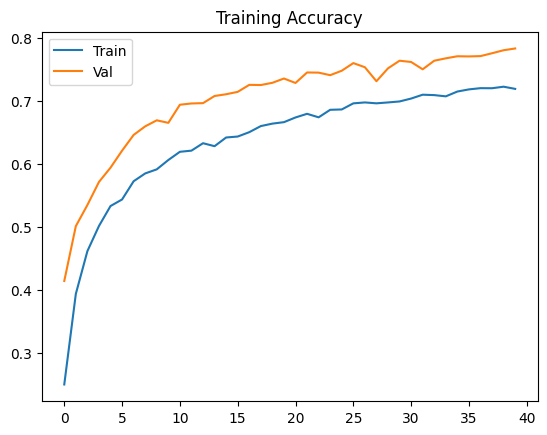

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.title("Training Accuracy")
plt.show()
